# Graph Neural Networks from Scratch

This notebook builds a **Graph Convolutional Network (GCN)** from first principles
using only NumPy — including the **backward pass by hand**, no autograd. As in the
XGBoost notebook, every step is first written as **mathematics** in a markdown cell,
then implemented in the **code cell** that follows, with the reasoning explained.

We will train a 2-layer GCN for **semi-supervised node classification**: given a graph
where only a handful of nodes are labeled, predict the class of every other node by
propagating information along the edges.

The plan:

1. Graphs and notation — adjacency, degree, features.
2. The core idea: message passing / neighborhood aggregation.
3. The GCN propagation rule and why we *symmetrically normalize* the adjacency.
4. The GCN layer (forward).
5. Activations and the softmax output.
6. The cross-entropy loss for the labeled nodes.
7. Backpropagation through the whole network, derived by hand.
8. The training loop (manual Adam).
9. A demo on a synthetic community graph, with embedding visualization.

> Notation: $N$ nodes, $A \in \{0,1\}^{N\times N}$ adjacency, $X \in \mathbb{R}^{N\times d}$
> node features (row $i$ = features of node $i$), and $C$ classes.

## 1. Graphs and notation

A graph is a set of $N$ **nodes** connected by **edges**. We encode the edges in an
**adjacency matrix** $A \in \mathbb{R}^{N\times N}$, where $A_{ij}=1$ if there is an
edge between node $i$ and node $j$ (we use undirected graphs, so $A = A^\top$).

Each node carries a feature vector; stacking them gives the **feature matrix**
$X \in \mathbb{R}^{N \times d}$. The **degree** of node $i$ is the number of neighbors,

$$
\deg(i) = \sum_{j} A_{ij},
$$

collected on the diagonal of the **degree matrix** $D = \mathrm{diag}(\deg(1),\dots,\deg(N))$.

**Reasoning:** unlike images (a fixed grid) or text (a sequence), a graph has no fixed
ordering or shape — each node has a different number of neighbors. The matrices
$A$, $D$, $X$ are the order-agnostic objects a GNN operates on, and everything below is
written as matrix algebra so it works for *any* graph.

## 2. The core idea: message passing

The single idea behind almost every GNN: **a node's new representation is a function of
its own features plus the aggregated features of its neighbors.** One round of this is
"message passing":

$$
h_i^{\text{new}} = \text{UPDATE}\Big(h_i,\; \text{AGGREGATE}\big(\{\,h_j : j \in \mathcal{N}(i)\,\}\big)\Big),
$$

where $\mathcal{N}(i)$ are the neighbors of $i$. If we choose AGGREGATE = *sum* and
UPDATE = *linear map then nonlinearity*, the per-node sum over neighbors is exactly a
**matrix multiply by $A$**:

$$
(A H)_i = \sum_{j} A_{ij}\, h_j = \sum_{j \in \mathcal{N}(i)} h_j .
$$

**Reasoning:** stacking $L$ message-passing layers lets information flow up to $L$ hops
across the graph, so a node's final embedding summarizes its whole $L$-hop neighborhood.
The magic is that the multiply $A H$ does this aggregation for *all* nodes
simultaneously — that single matrix product *is* the message passing.

## 3. The GCN propagation rule (and normalization)

Plain $AH$ has two problems: (1) it sums neighbors but **forgets the node itself**, and
(2) high-degree nodes produce huge sums while low-degree nodes produce tiny ones,
making scales explode across layers. The GCN of Kipf & Welling (2017) fixes both.

**Add self-loops** so each node includes itself in its neighborhood:

$$
\tilde{A} = A + I .
$$

**Symmetrically normalize** by degree. With $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$:

$$
\hat{A} = \tilde{D}^{-\frac{1}{2}}\, \tilde{A}\, \tilde{D}^{-\frac{1}{2}}
\qquad\Longleftrightarrow\qquad
\hat{A}_{ij} = \frac{\tilde{A}_{ij}}{\sqrt{\tilde{d}_i}\,\sqrt{\tilde{d}_j}} .
$$

This $\hat{A}$ is the fixed **propagation operator**. The GCN layer is then

$$
H^{(l+1)} = \sigma\!\Big( \hat{A}\, H^{(l)}\, W^{(l)} \Big),
$$

with $H^{(0)} = X$, a learnable weight $W^{(l)}$, and a nonlinearity $\sigma$.

**Reasoning:** $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$ weights the message from $j$ to
$i$ by $1/\sqrt{\tilde d_i \tilde d_j}$ — it down-weights popular neighbors and keeps the
spectrum of $\hat A$ in $[-1,1]$, so repeated multiplication stays numerically stable.
(It is a first-order approximation of a spectral graph convolution, hence the name.)
Crucially $\hat{A}$ depends only on the graph, so we compute it **once** and reuse it
every forward pass.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)
np.set_printoptions(precision=3, suppress=True)


def make_sbm(sizes, p_in, p_out, seed=0):
    """Sample an undirected graph from a Stochastic Block Model.

    `sizes` gives the number of nodes per community. Two nodes in the same
    community are connected with prob `p_in`, otherwise with prob `p_out`.
    Returns the adjacency A and the community label of every node.
    """
    r = np.random.RandomState(seed)
    labels = np.concatenate([np.full(s, k) for k, s in enumerate(sizes)])
    N = labels.size
    A = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            p = p_in if labels[i] == labels[j] else p_out
            if r.rand() < p:
                A[i, j] = A[j, i] = 1.0
    return A, labels


# 3 communities of 25 nodes; dense within, sparse across.
sizes = [25, 25, 25]
A, y = make_sbm(sizes, p_in=0.35, p_out=0.02, seed=1)
N = A.shape[0]
C = len(sizes)
print(f"graph: {N} nodes, {int(A.sum() // 2)} edges, {C} communities")
print(f"mean degree = {A.sum(1).mean():.2f}")

graph: 75 nodes, 352 edges, 3 communities
mean degree = 9.39


In [2]:
def normalize_adjacency(A):
    """Compute  A_hat = D~^{-1/2} (A + I) D~^{-1/2}  with self-loops."""
    A_tilde = A + np.eye(A.shape[0])          # add self-loops
    deg = A_tilde.sum(axis=1)                  # tilde-degree of each node
    d_inv_sqrt = 1.0 / np.sqrt(deg)            # D~^{-1/2} (diagonal)
    # Scale rows by d_i^{-1/2} and columns by d_j^{-1/2}:
    A_hat = d_inv_sqrt[:, None] * A_tilde * d_inv_sqrt[None, :]
    return A_hat


A_hat = normalize_adjacency(A)
# Sanity: A_hat is symmetric and its largest eigenvalue is <= 1.
print("symmetric:", np.allclose(A_hat, A_hat.T))
print("max |eigenvalue|:", np.abs(np.linalg.eigvalsh(A_hat)).max().round(3))

symmetric: True
max |eigenvalue|: 1.0


In [3]:
# Input features: the identity matrix (one-hot node IDs).
# This is the classic transductive GCN setup -- the model is given NO
# informative features and must learn purely from the graph structure.
X = np.eye(N)
d_in = X.shape[1]

# Semi-supervised split: reveal only a few labels per community.
labels_per_class = 4
train_mask = np.zeros(N, dtype=bool)
for c in range(C):
    idx = np.where(y == c)[0]
    train_mask[rng.choice(idx, labels_per_class, replace=False)] = True
test_mask = ~train_mask

# One-hot encode the targets (used only where train_mask is True).
Y = np.zeros((N, C))
Y[np.arange(N), y] = 1.0
print(f"labeled (train) nodes: {train_mask.sum()} / {N}")

labeled (train) nodes: 12 / 75


## 4. The GCN layer (forward)

Our network has two GCN layers. Write $\hat{A}$ for the propagation operator from step 3.
The forward pass is:

$$
\begin{aligned}
Z^{(1)} &= \hat{A}\, X\, W^{(1)}, & H^{(1)} &= \mathrm{ReLU}\big(Z^{(1)}\big),\\[4pt]
Z^{(2)} &= \hat{A}\, H^{(1)}\, W^{(2)}, & \hat{Y} &= \mathrm{softmax}\big(Z^{(2)}\big)\ \text{(row-wise)} .
\end{aligned}
$$

Shapes: $X\in\mathbb{R}^{N\times d}$, $W^{(1)}\in\mathbb{R}^{d\times H}$,
$W^{(2)}\in\mathbb{R}^{H\times C}$, and the output $\hat{Y}\in\mathbb{R}^{N\times C}$ is
a class distribution for **every** node.

**Reasoning:** each layer does two things at once — $\hat A(\cdot)$ mixes each node with
its neighbors (message passing), and right-multiplying by $W$ transforms the feature
space (a learned linear map shared across all nodes). Two layers means every node sees
its 2-hop neighborhood, which on our community graph is enough to "feel" which community
it sits in.

## 5. Activations and the softmax output

The hidden nonlinearity is **ReLU**, applied elementwise:

$$
\mathrm{ReLU}(z) = \max(0, z), \qquad \mathrm{ReLU}'(z) = \mathbb{1}[z > 0].
$$

The output layer turns each row of logits $z = Z^{(2)}_i \in \mathbb{R}^C$ into a
probability distribution with the **softmax**:

$$
\hat{Y}_{ic} = \mathrm{softmax}(z)_c = \frac{e^{z_c}}{\sum_{c'} e^{z_{c'}}} .
$$

**Reasoning:** ReLU gives the network nonlinearity (without it, stacking layers would
collapse to one linear map $\hat A^2 X W$). Softmax makes the outputs a valid
distribution over the $C$ classes so we can apply cross-entropy. We subtract the row max
before exponentiating — a standard trick that prevents overflow without changing the
result.

## 6. The loss: masked cross-entropy

Only the labeled (training) nodes contribute to the loss. With $L$ the set of labeled
nodes, the **masked cross-entropy** is

$$
\mathcal{L} = -\frac{1}{|L|}\sum_{i \in L}\sum_{c=1}^{C} Y_{ic}\,\log \hat{Y}_{ic} .
$$

**Reasoning:** this is *semi-supervised* learning. The unlabeled nodes still participate
in the **forward** pass — their features flow through $\hat A$ and shape the labeled
nodes' embeddings — but they contribute no gradient because we have no target for them.
Predictions for them come for free at inference time. This is exactly the regime GNNs
shine in: many nodes, few labels.

In [4]:
def relu(z):
    return np.maximum(0.0, z)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)     # numerical stability
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def forward(params, A_hat, X):
    """Two-layer GCN forward pass. Returns Yhat plus a cache for backprop."""
    W1, W2 = params["W1"], params["W2"]
    Z1 = A_hat @ X @ W1          # propagate, then transform
    H1 = relu(Z1)                # hidden activation
    Z2 = A_hat @ H1 @ W2         # propagate, then transform
    Yhat = softmax(Z2)           # per-node class distribution
    cache = {"X": X, "Z1": Z1, "H1": H1, "Z2": Z2, "Yhat": Yhat}
    return Yhat, cache

def masked_cross_entropy(Yhat, Y, mask):
    n = mask.sum()
    p = np.clip(Yhat[mask], 1e-12, 1.0)
    return -np.sum(Y[mask] * np.log(p)) / n

def accuracy(Yhat, y, mask):
    return np.mean(Yhat[mask].argmax(1) == y[mask])

## 7. Backpropagation, by hand

We need $\partial \mathcal{L} / \partial W^{(1)}$ and $\partial \mathcal{L} / \partial W^{(2)}$.
We propagate gradients backward through each operation. Two standard building blocks:

**Softmax + cross-entropy.** For the labeled nodes, the gradient of the loss w.r.t. the
logits collapses to the famous "predicted minus true":

$$
\frac{\partial \mathcal{L}}{\partial Z^{(2)}} \;=\; \frac{1}{|L|}\,M \odot \big(\hat{Y} - Y\big),
$$

where $M$ is the 0/1 row-mask (unlabeled rows are zeroed out). Call this $\delta_2$.

**Linear + propagation layer.** For a layer of the form $Z = \hat{A}\,H\,W$, let
$M = \hat A H$ so $Z = M W$. Standard matrix calculus gives

$$
\frac{\partial \mathcal{L}}{\partial W} = (\hat{A} H)^{\!\top}\,\delta,
\qquad
\frac{\partial \mathcal{L}}{\partial H} = \hat{A}^{\!\top}\,\big(\delta\, W^{\top}\big),
$$

using $\hat A^\top = \hat A$ (it is symmetric). Applying this twice, with the ReLU
derivative in between:

$$
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial W^{(2)}} &= \big(\hat{A} H^{(1)}\big)^{\!\top} \delta_2, &
\delta_1 &= \Big(\hat{A}\,\big(\delta_2 W^{(2)\top}\big)\Big) \odot \mathbb{1}[Z^{(1)}>0],\\[4pt]
\frac{\partial \mathcal{L}}{\partial W^{(1)}} &= \big(\hat{A} X\big)^{\!\top} \delta_1 . & &
\end{aligned}
$$

**Reasoning:** the gradient flows back through the *same* $\hat A$ used in the forward
pass — message passing happens in reverse during backprop, so a labeled node's error
signal reaches and updates the representations of its neighbors. This is why a few
labeled nodes can teach the whole graph.

In [5]:
def backward(params, cache, Y, mask, weight_decay=5e-4):
    W2 = params["W2"]
    X, Z1, H1, Yhat = cache["X"], cache["Z1"], cache["H1"], cache["Yhat"]
    n = mask.sum()

    # softmax + cross-entropy gradient, masked to labeled nodes only
    dZ2 = (Yhat - Y) * mask[:, None] / n          # delta_2  (N x C)

    # layer 2:  Z2 = A_hat @ H1 @ W2
    dW2 = (A_hat @ H1).T @ dZ2                     # (A_hat H1)^T delta_2
    dH1 = A_hat @ (dZ2 @ W2.T)                     # A_hat (delta_2 W2^T)

    # back through ReLU
    dZ1 = dH1 * (Z1 > 0)                           # delta_1

    # layer 1:  Z1 = A_hat @ X @ W1
    dW1 = (A_hat @ X).T @ dZ1                      # (A_hat X)^T delta_1

    # L2 weight decay (regularization) adds wd * W to each gradient
    dW1 += weight_decay * params["W1"]
    dW2 += weight_decay * W2
    return {"W1": dW1, "W2": dW2}

## 8. Training loop (manual Adam)

We optimize $W^{(1)}, W^{(2)}$ by gradient descent. Plain SGD converges slowly here, so
we implement **Adam** by hand. For each parameter $\theta$ with gradient $g_t$:

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1) g_t, & \hat{m}_t &= m_t / (1 - \beta_1^{\,t}),\\
v_t &= \beta_2 v_{t-1} + (1-\beta_2) g_t^2, & \hat{v}_t &= v_t / (1 - \beta_2^{\,t}),\\
\theta &\leftarrow \theta - \eta\, \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon). & &
\end{aligned}
$$

Weights are initialized with **Glorot/Xavier** uniform init,
$W \sim \mathcal{U}\big[-\sqrt{6/(\text{fan}_{in}+\text{fan}_{out})},\, +\sqrt{\cdots}\big]$,
which keeps activation variance stable across layers.

**Reasoning:** $m_t$ is a running mean of the gradient (momentum) and $v_t$ a running
mean of its square; dividing by $\sqrt{\hat v_t}$ gives each weight its own adaptive step
size, so we converge in a few hundred full-batch steps instead of many thousands. The
bias-correction terms $1-\beta^t$ matter only in the first iterations when $m,v$ are
still warming up from zero.

In [6]:
def glorot(shape, seed):
    r = np.random.RandomState(seed)
    limit = np.sqrt(6.0 / (shape[0] + shape[1]))
    return r.uniform(-limit, limit, size=shape)

class Adam:
    def __init__(self, params, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.b1 ** self.t)
            v_hat = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params

In [7]:
hidden = 16
params = {
    "W1": glorot((d_in, hidden), seed=2),
    "W2": glorot((hidden, C), seed=3),
}
opt = Adam(params, lr=0.02)

epochs = 300
history = {"loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
    Yhat, cache = forward(params, A_hat, X)
    grads = backward(params, cache, Y, train_mask, weight_decay=5e-4)
    params = opt.step(params, grads)

    loss = masked_cross_entropy(Yhat, Y, train_mask)
    history["loss"].append(loss)
    history["train_acc"].append(accuracy(Yhat, y, train_mask))
    history["test_acc"].append(accuracy(Yhat, y, test_mask))
    if epoch % 30 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d}  loss {loss:.4f}  "
              f"train_acc {history['train_acc'][-1]:.3f}  "
              f"test_acc {history['test_acc'][-1]:.3f}")

Yhat, _ = forward(params, A_hat, X)
print(f"\nFinal test accuracy (on {test_mask.sum()} unlabeled nodes): "
      f"{accuracy(Yhat, y, test_mask):.3f}")

epoch   0  loss 1.0972  train_acc 0.333  test_acc 0.333
epoch  30  loss 0.0691  train_acc 1.000  test_acc 1.000
epoch  60  loss 0.0115  train_acc 1.000  test_acc 1.000
epoch  90  loss 0.0151  train_acc 1.000  test_acc 1.000
epoch 120  loss 0.0147  train_acc 1.000  test_acc 1.000
epoch 150  loss 0.0131  train_acc 1.000  test_acc 1.000
epoch 180  loss 0.0120  train_acc 1.000  test_acc 1.000
epoch 210  loss 0.0112  train_acc 1.000  test_acc 1.000
epoch 240  loss 0.0106  train_acc 1.000  test_acc 1.000
epoch 270  loss 0.0101  train_acc 1.000  test_acc 1.000
epoch 299  loss 0.0097  train_acc 1.000  test_acc 1.000

Final test accuracy (on 63 unlabeled nodes): 1.000


## 9. Results: curves and learned embeddings

Two views of what happened:

1. **Learning curves** — loss falls and test accuracy climbs as the few labels
   propagate across the graph.
2. **Node embeddings** — we take the hidden representation $H^{(1)} \in \mathbb{R}^{N\times H}$
   and project it to 2D with PCA. If message passing worked, nodes from the same
   community should cluster together even though most were never labeled.

**Reasoning:** the embedding plot is the real payoff. We fed the model *no* node features
(just identity), labeled only a dozen nodes, yet the communities separate cleanly — the
structure of the graph alone, pushed through $\hat A$, organized the representation.

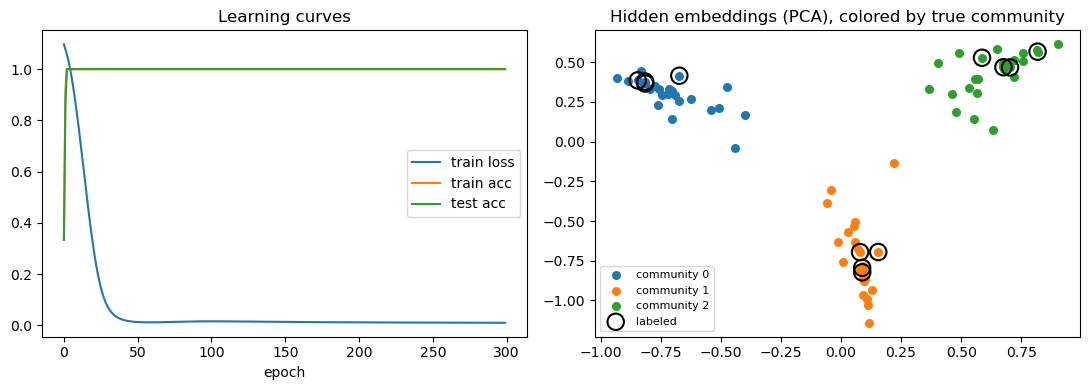

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history["loss"], label="train loss")
ax[0].plot(history["train_acc"], label="train acc")
ax[0].plot(history["test_acc"], label="test acc")
ax[0].set_xlabel("epoch"); ax[0].set_title("Learning curves"); ax[0].legend()

# PCA of the hidden embeddings H1 (via SVD on the centered matrix).
H1 = relu(A_hat @ X @ params["W1"])
Hc = H1 - H1.mean(0, keepdims=True)
U, S, Vt = np.linalg.svd(Hc, full_matrices=False)
emb2d = Hc @ Vt[:2].T

for c in range(C):
    m = y == c
    ax[1].scatter(emb2d[m, 0], emb2d[m, 1], label=f"community {c}", s=30)
# Mark the labeled nodes with a black ring.
ax[1].scatter(emb2d[train_mask, 0], emb2d[train_mask, 1],
              s=140, facecolors="none", edgecolors="k", linewidths=1.5,
              label="labeled")
ax[1].set_title("Hidden embeddings (PCA), colored by true community")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

We derived and implemented a GCN end to end:

| Step | Math | Where in code |
|------|------|---------------|
| 1 | adjacency $A$, degree $D$, features $X$ | `make_sbm`, `X` |
| 3 | normalize $\hat A = \tilde D^{-1/2}\tilde A\tilde D^{-1/2}$ | `normalize_adjacency` |
| 4 | layer $H^{(l+1)}=\sigma(\hat A H^{(l)} W^{(l)})$ | `forward` |
| 5 | ReLU + softmax | `relu`, `softmax` |
| 6 | masked cross-entropy | `masked_cross_entropy` |
| 7 | hand-derived gradients | `backward` |
| 8 | Adam + Glorot init | `Adam`, `glorot` |

The two ideas that make a GNN work: (1) **message passing is a matrix multiply** —
$\hat A H$ aggregates every node's neighborhood at once, and stacking layers grows the
receptive field hop by hop; and (2) the **same propagation operator carries gradients
backward**, so a handful of labeled nodes can supervise an entire graph.

Natural extensions: GraphSAGE (sample-and-aggregate with mean/max/LSTM aggregators),
Graph Attention Networks (learn per-edge weights instead of the fixed degree
normalization), edge features, mini-batch neighbor sampling for large graphs, and
graph-level tasks via a readout that pools all node embeddings into one vector.